# 🫀 LSTM Patient Monitoring

---


| Improvement | Why It Helps |
|---|---|
| Dual-channel input (MLII + V1) | 2x signal information |
| Wider window (280 samples) | Captures full P-QRS-T complex |
| Multi-scale CNN (kernels 3,7,15) | Detects features at multiple resolutions |
| Bidirectional LSTM | Forward + backward ECG context |
| Multi-head self-attention | Global context over entire beat |
| RR interval features | Inter-beat timing critical for arrhythmia |
| Morphological features (24) | Clinical hand-crafted signal features |
| Focal Loss + Label Smoothing | Best loss for imbalanced medical data |
| Mixup augmentation | Harder training samples, better generalization |
| Threshold optimization | Optimal decision boundary on val set |



## 📌 Step 1 — Setup: Mount Drive, Install & Import Libraries

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print('✅ Google Drive mounted')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive mounted


In [ ]:
!pip install wfdb scikit-learn imbalanced-learn scipy numpy pandas matplotlib seaborn tqdm -q
print('✅ Libraries installed')

✅ Libraries installed


In [ ]:
import os, json, warnings, time, shutil, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import wfdb
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
from scipy.signal import butter, filtfilt, welch
from scipy.stats import skew, kurtosis
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    f1_score, precision_score, recall_score,
    average_precision_score
)
from tqdm import tqdm
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ All imports successful')
print(f'   PyTorch  : {torch.__version__}')
print(f'   Device   : {device}')
if device.type == 'cuda':
    print(f'   GPU      : {torch.cuda.get_device_name(0)}')
    print(f'   VRAM     : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
else:
    print('   ⚠️  No GPU detected — Go to Runtime → Change runtime type → T4 GPU')

plt.style.use('dark_background')
BG = '#0f0f1a'
torch.manual_seed(42)
np.random.seed(42)

✅ All imports successful
   PyTorch  : 2.9.0+cu128
   Device   : cuda
   GPU      : Tesla T4
   VRAM     : 15.6 GB


## 📌 Step 2 — Global Configuration


In [ ]:

DRIVE_RAW_DIR  = '/content/drive/MyDrive/mit-bih-arrhythmia-database-1.0.0'
LOCAL_RAW_DIR  = '/content/mit-bih-raw'
LOCAL_PROC_DIR = '/content/mit-bih-processed'
MODEL_SAVE_DIR = '/content/drive/MyDrive/mit-bih-v2-models'
for d in [LOCAL_RAW_DIR, LOCAL_PROC_DIR, MODEL_SAVE_DIR]:
    os.makedirs(d, exist_ok=True)


FS             = 360
LOWCUT         = 0.5
HIGHCUT        = 45.0
FILTER_ORDER   = 4

WINDOW_BEFORE  = 100
WINDOW_AFTER   = 180
SEGMENT_LEN    = WINDOW_BEFORE + WINDOW_AFTER

NORMAL_BEATS   = ['N', 'L', 'R', 'e', 'j']
ANOMALY_BEATS  = ['V', 'A', 'a', 'J', 'S', 'F', 'E', '/', 'f', 'x', 'Q']


BATCH_SIZE      = 64
LEARNING_RATE   = 3e-4
NUM_EPOCHS      = 80
HIDDEN_SIZE     = 256
NUM_LAYERS      = 3
DROPOUT         = 0.4
PATIENCE        = 15
LABEL_SMOOTHING = 0.1


ALL_RECORDS = [
    '100','101','102','103','104','105','106','107',
    '108','109','111','112','113','114','115','116',
    '117','118','119','121','122','123','124','200',
    '201','202','203','205','207','208','209','210',
    '212','213','214','215','217','219','220','221',
    '222','223','228','230','231','232','233','234'
]

print('✅ Configuration loaded')
print(f'   Segment    : {SEGMENT_LEN} samples  ({SEGMENT_LEN/FS*1000:.0f} ms per beat)')
print(f'   Hidden     : {HIDDEN_SIZE}   Layers : {NUM_LAYERS}')
print(f'   Batch      : {BATCH_SIZE}    LR     : {LEARNING_RATE}')
print(f'   Epochs     : {NUM_EPOCHS}    Patience: {PATIENCE}')

✅ Configuration loaded
   Segment    : 280 samples  (778 ms per beat)
   Hidden     : 256   Layers : 3
   Batch      : 64    LR     : 0.0003
   Epochs     : 80    Patience: 15


## 📌 Step 3 — Copy Raw Data to Local Storage
Prevents Drive disconnection errors during processing

In [ ]:
def copy_raw_data(drive_dir=DRIVE_RAW_DIR, local_dir=LOCAL_RAW_DIR):
    if not os.path.exists(drive_dir):
        raise FileNotFoundError(
            f'Raw data not found at: {drive_dir}\n'
            f'Upload your MIT-BIH folder to Google Drive first!'
        )
    files = os.listdir(drive_dir)
    print(f'🔄 Copying {len(files)} files to local /content/ ...')
    for fname in tqdm(files, desc='Copying'):
        src, dst = os.path.join(drive_dir, fname), os.path.join(local_dir, fname)

        if os.path.isfile(src) and not os.path.exists(dst):
            shutil.copy2(src, dst)
    dat_count = len([f for f in os.listdir(local_dir) if f.endswith('.dat')])
    print(f'✅ {dat_count} records ready at: {local_dir}')

copy_raw_data()

🔄 Copying 207 files to local /content/ ...


Copying: 100%|██████████| 207/207 [00:15<00:00, 13.10it/s]

✅ 48 records ready at: /content/mit-bih-raw


## 📌 Step 4 — Signal Preprocessing

In [ ]:
def bandpass_filter(signal, lowcut=LOWCUT, highcut=HIGHCUT, fs=FS, order=FILTER_ORDER):
    """Zero-phase Butterworth bandpass filter."""
    nyq  = 0.5 * fs
    b, a = butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return filtfilt(b, a, signal)


def compute_rr_features(r_peaks, idx, fs=FS, window=5):
    """
    6 RR-interval features around a beat.
    Critical for detecting: A-fib (irregular RR), PVC (short pre / long post RR),
    tachycardia (all RR short), bradycardia (all RR long).
    """
    pre_rr = post_rr = rr_mean = rr_std = rr_ratio = norm_rr = 0.0
    if idx > 0:
        pre_rr  = (r_peaks[idx] - r_peaks[idx-1]) / fs * 1000
    if idx < len(r_peaks) - 1:
        post_rr = (r_peaks[idx+1] - r_peaks[idx]) / fs * 1000
    s = max(0, idx - window)
    e = min(len(r_peaks) - 1, idx + window)
    if e > s + 1:
        local  = np.diff(r_peaks[s:e+1]) / fs * 1000
        rr_mean  = local.mean()
        rr_std   = local.std()
        rr_ratio = pre_rr / (post_rr + 1e-8)
        norm_rr  = pre_rr / (rr_mean + 1e-8)
    return np.array([pre_rr, post_rr, rr_mean, rr_std, rr_ratio, norm_rr], dtype=np.float32)


def extract_morph_features(seg_ch0, seg_ch1, fs=FS):
    """24 morphological features (12 per channel)."""
    feats = []
    for seg in [seg_ch0, seg_ch1]:
        p2p   = seg.max() - seg.min()
        thresh = 0.5 * p2p + seg.min()
        freqs, psd = welch(seg, fs=fs, nperseg=min(len(seg), 64))
        tp    = np.sum(psd)
        lf    = np.sum(psd[(freqs>=0.5)&(freqs<=15)]) / (tp + 1e-8)
        feats.extend([
            seg.mean(), seg.std(), seg.var(),
            float(skew(seg)), float(kurtosis(seg)),
            np.sqrt(np.mean(seg**2)),     # RMS
            p2p, seg[WINDOW_BEFORE],      # peak-to-peak, R-peak value
            np.sum(seg**2),               # energy
            float(np.sum(np.diff(np.sign(seg)) != 0)),  # zero crossings
            float(np.sum(seg > thresh)),  # QRS width estimate
            lf                            # LF power ratio
        ])
    return np.array(feats, dtype=np.float32)


def zscore(seg):
    return (seg - seg.mean()) / (seg.std() + 1e-8)


print('✅ Preprocessing functions defined')

✅ Preprocessing functions defined


In [ ]:
def segment_record(record_id, data_dir=LOCAL_RAW_DIR):
    """
    Extract dual-channel beat segments with RR + morphological features.
    Returns:
        segs_2ch : (N, SEGMENT_LEN, 2)  normalized dual-channel signal
        rr_feats : (N, 6)
        morph_f  : (N, 24)
        labels   : (N,)   0=Normal  1=Anomaly
        symbols  : list
    """
    path   = os.path.join(data_dir, record_id)
    rec    = wfdb.rdrecord(path)
    ann    = wfdb.rdann(path, 'atr')
    siglen = rec.p_signal.shape[0]

    # Filter available channels; duplicate if only 1
    chs = [bandpass_filter(rec.p_signal[:, c]) for c in range(min(2, rec.n_sig))]
    if len(chs) == 1:
        chs.append(chs[0].copy())
    ch0, ch1 = chs[0], chs[1]

    beats = [(s, sym) for s, sym in zip(ann.sample, ann.symbol)
             if sym in NORMAL_BEATS + ANOMALY_BEATS]
    r_peaks = np.array([b[0] for b in beats])

    segs_2ch, rr_feats, morph_f, labels, syms = [], [], [], [], []

    for i, (r, sym) in enumerate(beats):
        s, e = r - WINDOW_BEFORE, r + WINDOW_AFTER
        if s < 0 or e > siglen:
            continue
        seg0 = zscore(ch0[s:e])
        seg1 = zscore(ch1[s:e])
        segs_2ch.append(np.stack([seg0, seg1], axis=-1))
        rr_feats.append(compute_rr_features(r_peaks, i))
        morph_f.append(extract_morph_features(seg0, seg1))
        labels.append(0 if sym in NORMAL_BEATS else 1)
        syms.append(sym)

    return (np.array(segs_2ch,  dtype=np.float32),
            np.array(rr_feats,  dtype=np.float32),
            np.array(morph_f,   dtype=np.float32),
            np.array(labels,    dtype=np.int64),
            syms)


def process_all_records():
    all_segs, all_rr, all_morph, all_y, all_rids = [], [], [], [], []
    print(f'🔄 Processing {len(ALL_RECORDS)} records (dual-channel + RR features)...')
    for rid in tqdm(ALL_RECORDS, desc='Records'):
        try:
            s, r, m, y, _ = segment_record(rid)
            if len(s) == 0: continue
            all_segs.append(s);  all_rr.append(r)
            all_morph.append(m); all_y.append(y)
            all_rids.extend([rid]*len(y))
        except Exception as ex:
            print(f'\n⚠️  {rid}: {ex}')

    X_sig   = np.vstack(all_segs)
    X_rr    = np.vstack(all_rr)
    X_morph = np.vstack(all_morph)
    y       = np.hstack(all_y)

    print(f'\n✅ Done!')
    print(f'   Beats extracted : {len(y):,}')
    print(f'   Signal shape    : {X_sig.shape}   (N, {SEGMENT_LEN}, 2) dual-channel')
    print(f'   RR shape        : {X_rr.shape}')
    print(f'   Morph shape     : {X_morph.shape}')
    print(f'   Normal  : {(y==0).sum():,}  ({100*(y==0).mean():.1f}%)')
    print(f'   Anomaly : {(y==1).sum():,}  ({100*(y==1).mean():.1f}%)')
    return X_sig, X_rr, X_morph, y, all_rids

X_sig, X_rr, X_morph, y_all, all_rids = process_all_records()

🔄 Processing 48 records (dual-channel + RR features)...


Records: 100%|██████████| 48/48 [09:30<00:00, 11.89s/it]


✅ Done!
   Beats extracted : 109,641
   Signal shape    : (109641, 280, 2)   (N, 280, 2) dual-channel
   RR shape        : (109641, 6)
   Morph shape     : (109641, 24)
   Normal  : 90,591  (82.6%)
   Anomaly : 19,050  (17.4%)


## 📌 Step 5 — Patient-Wise Split (No Data Leakage) + Feature Normalization

In [ ]:
def patient_wise_split(X_sig, X_rr, X_morph, y, rids, seed=42):
    np.random.seed(seed)
    uniq = np.array(list(set(rids)))
    np.random.shuffle(uniq)
    n = len(uniq)
    tr_recs = set(uniq[:int(n*0.70)])
    va_recs = set(uniq[int(n*0.70):int(n*0.85)])
    te_recs = set(uniq[int(n*0.85):])

    rids_arr = np.array(rids)
    splits = {}
    for name, rset in [('train',tr_recs),('val',va_recs),('test',te_recs)]:
        m = np.isin(rids_arr, list(rset))
        splits[name] = {'X_sig':X_sig[m], 'X_rr':X_rr[m],
                        'X_morph':X_morph[m], 'y':y[m]}

    # Normalize RR + morph using TRAINING stats only (prevents leakage)
    rr_sc    = StandardScaler().fit(splits['train']['X_rr'])
    morph_sc = StandardScaler().fit(splits['train']['X_morph'])
    for sp in splits.values():
        sp['X_rr']    = rr_sc.transform(sp['X_rr']).astype(np.float32)
        sp['X_morph'] = morph_sc.transform(sp['X_morph']).astype(np.float32)

    print('✅ Patient-wise split complete')
    print(f'\n   {"Split":<8} {"Records":<10} {"Beats":<12} {"Normal":<12} {"Anomaly":<10} {"Anomaly%"}')
    print(f'   {"─"*62}')
    for nm, rs in [('Train',tr_recs),('Val',va_recs),('Test',te_recs)]:
        yy = splits[nm.lower()]['y']
        print(f'   {nm:<8} {len(rs):<10} {len(yy):<12,} {(yy==0).sum():<12,} '
              f'{(yy==1).sum():<10,} {100*(yy==1).mean():.1f}%')
    return splits, rr_sc, morph_sc

splits, rr_scaler, morph_scaler = patient_wise_split(X_sig, X_rr, X_morph, y_all, all_rids)

✅ Patient-wise split complete

   Split    Records    Beats        Normal       Anomaly    Anomaly%
   ──────────────────────────────────────────────────────────────
   Train    33         74,870       61,078       13,792     18.4%
   Val      7          17,191       13,819       3,372      19.6%
   Test     8          17,580       15,694       1,886      10.7%


## 📌 Step 6 — Dataset with Signal Augmentation
ry

In [ ]:
class ECGDataset(Dataset):
    def __init__(self, split_dict, augment=False):
        self.X_sig   = torch.FloatTensor(split_dict['X_sig'])
        self.X_rr    = torch.FloatTensor(split_dict['X_rr'])
        self.X_morph = torch.FloatTensor(split_dict['X_morph'])
        self.y       = torch.LongTensor(split_dict['y'])
        self.augment = augment

    def __len__(self): return len(self.y)

    def __getitem__(self, idx):
        sig, rr, morph, lbl = (self.X_sig[idx], self.X_rr[idx],
                               self.X_morph[idx], self.y[idx])
        if self.augment and np.random.random() < 0.5:
            scale = np.random.uniform(0.8, 1.2)
            sig   = sig * scale + torch.randn_like(sig) * 0.02
        return sig, rr, morph, lbl


def mixup_batch(sig, rr, morph, labels, alpha=0.3):
    if alpha <= 0:
        return sig, rr, morph, labels, labels, 1.0
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(sig.size(0)).to(sig.device)
    return (lam*sig + (1-lam)*sig[idx],
            lam*rr  + (1-lam)*rr[idx],
            lam*morph + (1-lam)*morph[idx],
            labels, labels[idx], lam)


train_loader = DataLoader(ECGDataset(splits['train'], augment=True),
                          batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(ECGDataset(splits['val'],   augment=False),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(ECGDataset(splits['test'],  augment=False),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

n_nor = (splits['train']['y']==0).sum()
n_ano = (splits['train']['y']==1).sum()
class_weights = torch.FloatTensor([1.0, min(n_nor/n_ano, 5.0)]).to(device)

print(f'✅ DataLoaders ready')
print(f'   Train: {len(train_loader)} batches  Val: {len(val_loader)}  Test: {len(test_loader)}')
print(f'   Class weights → Normal: 1.00   Anomaly: {class_weights[1].item():.2f}')

✅ DataLoaders ready
   Train: 1170 batches  Val: 269  Test: 275
   Class weights → Normal: 1.00   Anomaly: 4.43


## 📌 Step 7 — Model Architecture: Multi-Scale CNN + BiLSTM + Attention
```
Input: Dual-channel signal  (batch, 280, 2)
           ↓
  ┌─────────────────────────────────────┐
  │       Multi-Scale CNN Block         │
  │  Branch-S: Conv1D kernel=3  → 64ch │  Fine detail (R-peaks, notches)
  │  Branch-M: Conv1D kernel=7  → 64ch │  QRS complex morphology
  │  Branch-L: Conv1D kernel=15 → 64ch │  P and T wave shape
  │  Concatenate → 192 channels         │
  │  MaxPool(4) → seq_len: 280 → 70    │
  └─────────────────────────────────────┘
           ↓  (batch, 70, 192)
  Bidirectional LSTM  (3 layers, 256 hidden × 2 directions = 512)
           ↓  (batch, 70, 512)
  Multi-Head Self-Attention  (8 heads)
           ↓  context vector  (batch, 512)
  Concatenate RR features (6) + Morph features (24)  → (batch, 542)
           ↓
  Classifier FC: 542 → 256 → 128 → 2
           ↓
  Output: Normal / Anomaly
```

In [ ]:
class MultiScaleCNN(nn.Module):
    def __init__(self, in_ch=2, out_ch=64):
        super().__init__()
        def branch(k):
            return nn.Sequential(
                nn.Conv1d(in_ch, out_ch, k, padding=k//2, bias=False),
                nn.BatchNorm1d(out_ch), nn.GELU(),
                nn.Conv1d(out_ch, out_ch, k, padding=k//2, bias=False),
                nn.BatchNorm1d(out_ch), nn.GELU(),
                nn.Dropout(0.2)
            )
        self.s = branch(3)
        self.m = branch(7)
        self.l = branch(15)
        self.pool = nn.MaxPool1d(4, stride=4)

    def forward(self, x):

        x = x.permute(0, 2, 1)
        out = torch.cat([self.s(x), self.m(x), self.l(x)], dim=1)
        return self.pool(out).permute(0, 2, 1)


class SelfAttention(nn.Module):
    def __init__(self, dim, heads=8):
        super().__init__()
        self.attn = nn.MultiheadAttention(dim, heads, dropout=0.1, batch_first=True)
        self.norm = nn.LayerNorm(dim)

    def forward(self, x):
        out, w = self.attn(x, x, x)
        return self.norm(x + out).mean(dim=1), w   \

class HighPerfECGModel(nn.Module):
    """
    Multi-Scale CNN + Bidirectional LSTM + Multi-Head Attention
    with RR interval and morphological feature fusion.
    """
    def __init__(self):
        super().__init__()
        self.cnn     = MultiScaleCNN(in_ch=2, out_ch=64)
        self.bilstm  = nn.LSTM(192, HIDDEN_SIZE, NUM_LAYERS,
                               batch_first=True, bidirectional=True,
                               dropout=DROPOUT if NUM_LAYERS>1 else 0)
        bilstm_out   = HIDDEN_SIZE * 2
        self.attn    = SelfAttention(bilstm_out, heads=8)
        fusion_dim   = bilstm_out + 6 + 24
        self.norm    = nn.LayerNorm(fusion_dim)
        self.clf     = nn.Sequential(
            nn.Linear(fusion_dim, 256), nn.GELU(), nn.Dropout(DROPOUT), nn.LayerNorm(256),
            nn.Linear(256, 128),        nn.GELU(), nn.Dropout(DROPOUT/2),
            nn.Linear(128, 2)
        )

    def forward(self, x_sig, x_rr, x_morph):
        cnn_out        = self.cnn(x_sig)
        lstm_out, _    = self.bilstm(cnn_out)
        context, _     = self.attn(lstm_out)
        fused          = torch.cat([context, x_rr, x_morph], dim=1)
        return self.clf(self.norm(fused))


model = HighPerfECGModel().to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'✅ High-Performance ECG Model built')
print(f'   Parameters   : {n_params:,}')
print(f'   Architecture : MultiScale-CNN → BiLSTM({HIDDEN_SIZE}×2) → Attention → Fusion → FC')

# Smoke test
with torch.no_grad():
    out = model(torch.randn(4,SEGMENT_LEN,2).to(device),
                torch.randn(4,6).to(device),
                torch.randn(4,24).to(device))
print(f'   Output shape : {out.shape}  ✅ Forward pass OK')

✅ High-Performance ECG Model built
   Parameters   : 5,407,294
   Architecture : MultiScale-CNN → BiLSTM(256×2) → Attention → Fusion → FC
   Output shape : torch.Size([4, 2])  ✅ Forward pass OK


## 📌 Step 8 — Loss Function: Focal Loss + Label Smoothing
Combines two techniques designed for imbalanced medical classification:
- **Focal Loss**: down-weights easy correct predictions, focuses on hard anomaly samples
- **Label Smoothing**: replaces hard 0/1 labels with soft 0.05/0.95 — prevents overconfidence

In [ ]:
class FocalLossSmoothed(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, smoothing=LABEL_SMOOTHING, weight=None):
        super().__init__()
        self.alpha, self.gamma = alpha, gamma
        self.smoothing, self.weight = smoothing, weight

    def forward(self, logits, targets):
        # Soft labels
        with torch.no_grad():
            soft = torch.full_like(logits, self.smoothing / 1)
            soft.scatter_(1, targets.unsqueeze(1), 1.0 - self.smoothing)
        log_p  = F.log_softmax(logits, dim=1)
        ce     = -(soft * log_p).sum(dim=1)
        pt     = torch.exp(-F.cross_entropy(logits, targets,
                            weight=self.weight, reduction='none'))
        return (self.alpha * (1-pt)**self.gamma * ce).mean()

criterion = FocalLossSmoothed(alpha=0.25, gamma=2.0,
                               smoothing=LABEL_SMOOTHING, weight=class_weights)
print(f'✅ Focal Loss + Label Smoothing ready')
print(f'   alpha={0.25}  gamma={2.0}  smoothing={LABEL_SMOOTHING}  anomaly_weight={class_weights[1].item():.2f}')

✅ Focal Loss + Label Smoothing ready
   alpha=0.25  gamma=2.0  smoothing=0.1  anomaly_weight=4.43


## 📌 Step 9 — Training Engine with Warmup + Cosine Annealing

In [ ]:
class EarlyStopping:
    def __init__(self, patience=PATIENCE):
        self.patience = patience
        self.best = -1.0
        self.counter = 0
        self.triggered = False

    def step(self, val_f1):
        if val_f1 > self.best + 1e-4:
            self.best = val_f1
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.triggered = True
        return self.triggered


def run_epoch(model, loader, optimizer=None, use_mixup=False):
    """Single train or eval epoch."""
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss = correct = total = 0
    all_preds, all_probs, all_labels = [], [], []

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for sig, rr, morph, labels in loader:
            sig, rr, morph, labels = (sig.to(device), rr.to(device),
                                      morph.to(device), labels.to(device))
            if is_train and use_mixup:
                sig, rr, morph, la, lb, lam = mixup_batch(sig, rr, morph, labels)
                logits = model(sig, rr, morph)
                loss   = lam * criterion(logits, la) + (1-lam) * criterion(logits, lb)
            else:
                logits = model(sig, rr, morph)
                loss   = criterion(logits, labels)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            probs  = torch.softmax(logits, dim=1)[:,1]
            preds  = logits.argmax(dim=1)
            total_loss += loss.item() * len(labels)
            correct    += (preds == labels).sum().item()
            total      += len(labels)
            # Fix: Added .detach() before .numpy() to prevent RuntimeError
            all_preds.extend(preds.detach().cpu().numpy())
            all_probs.extend(probs.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())

    avg_loss = total_loss / total
    acc      = 100 * correct / total
    f1       = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    try:
        auc = roc_auc_score(all_labels, all_probs)
    except Exception:
        auc = 0.0
    return avg_loss, acc, f1, auc, np.array(all_preds), np.array(all_probs), np.array(all_labels)


def train_model(model, train_loader, val_loader,
                num_epochs=NUM_EPOCHS, lr=LEARNING_RATE,
                name='hp_ecg_model', save_dir=MODEL_SAVE_DIR):

    optimizer  = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-3)
    warmup_ep  = 5

    def lr_lambda(ep):
        if ep < warmup_ep:
            return (ep + 1) / warmup_ep
        prog = (ep - warmup_ep) / max(1, num_epochs - warmup_ep)
        return 0.5 * (1 + np.cos(np.pi * prog))

    scheduler  = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    stopper    = EarlyStopping(PATIENCE)
    history    = {k:[] for k in ['tl','vl','ta','va','vf1','vauc','lr']}
    best_auc   = 0.0

    print(f'\n  Training: {name}')
    print(f'   LR: {lr} → warmup({warmup_ep}ep) → cosine decay')
    print(f'   Mixup: ON  |  Label smoothing: {LABEL_SMOOTHING}  |  Device: {device}')
    print('─'*80)
    print(f'  {"Ep":<5}{"TrLoss":<9}{"VaLoss":<9}{"TrAcc":<9}{"VaAcc":<9}'
          f'{"VaF1":<9}{"VaAUC":<9}{"LR"}')
    print('─'*80)

    t0 = time.time()
    for epoch in range(1, num_epochs+1):
        tl, ta, tf1, _, _, _, _ = run_epoch(model, train_loader, optimizer, use_mixup=True)
        vl, va, vf1, vauc, _, _, _ = run_epoch(model, val_loader)
        scheduler.step()
        curr_lr = optimizer.param_groups[0]['lr']

        for k,v in zip(history.keys(), [tl,vl,ta,va,vf1,vauc,curr_lr]):
            history[k].append(v)

        star = ''
        if vauc > best_auc:
            best_auc = vauc
            torch.save({'epoch':epoch, 'state':model.state_dict(),
                        'auc':vauc, 'f1':vf1}, os.path.join(save_dir, f'{name}_best.pt'))
            star = '  '

        if epoch % 5 == 0 or epoch == 1:
            print(f'  {epoch:<5}{tl:<9.4f}{vl:<9.4f}{ta:<9.2f}'
                  f'{va:<9.2f}{vf1:<9.4f}{vauc:<9.4f}{curr_lr:.2e}{star}')

        if stopper.step(vf1):
            print(f'\n    Early stopping at epoch {epoch}')
            break

    print('─'*80)
    print(f'  ✅ Done in {(time.time()-t0)/60:.1f} min  |  Best Val AUC: {best_auc:.4f}')
    ckpt = torch.load(os.path.join(save_dir, f'{name}_best.pt'), weights_only=False)
    model.load_state_dict(ckpt['state'])
    print(f'  Loaded best checkpoint (epoch {ckpt["epoch"]})')
    return model, history

## 📌 Step 10 — Train the Model
> This will take ~30–50 minutes on T4 GPU. Training progress printed every 5 epochs.

In [ ]:
model, history = train_model(
    model, train_loader, val_loader,
    num_epochs = NUM_EPOCHS,
    lr         = LEARNING_RATE,
    name       = 'hp_ecg_model'
)


  Training: hp_ecg_model
   LR: 0.0003 → warmup(5ep) → cosine decay
   Mixup: ON  |  Label smoothing: 0.1  |  Device: cuda
────────────────────────────────────────────────────────────────────────────────
  Ep   TrLoss   VaLoss   TrAcc    VaAcc    VaF1     VaAUC    LR
────────────────────────────────────────────────────────────────────────────────
  1    0.0149   0.0504   85.27    76.89    0.7269   0.9689   1.20e-04  
  5    0.0155   0.0507   84.65    79.57    0.7513   0.9669   3.00e-04
  10   0.0151   0.0535   85.13    77.79    0.7307   0.9517   2.97e-04
  15   0.0145   0.0550   84.70    79.76    0.7534   0.9593   2.87e-04

    Early stopping at epoch 19
────────────────────────────────────────────────────────────────────────────────
  ✅ Done in 27.9 min  |  Best Val AUC: 0.9742
  Loaded best checkpoint (epoch 7)


## 📌 Step 11 — Training Curves

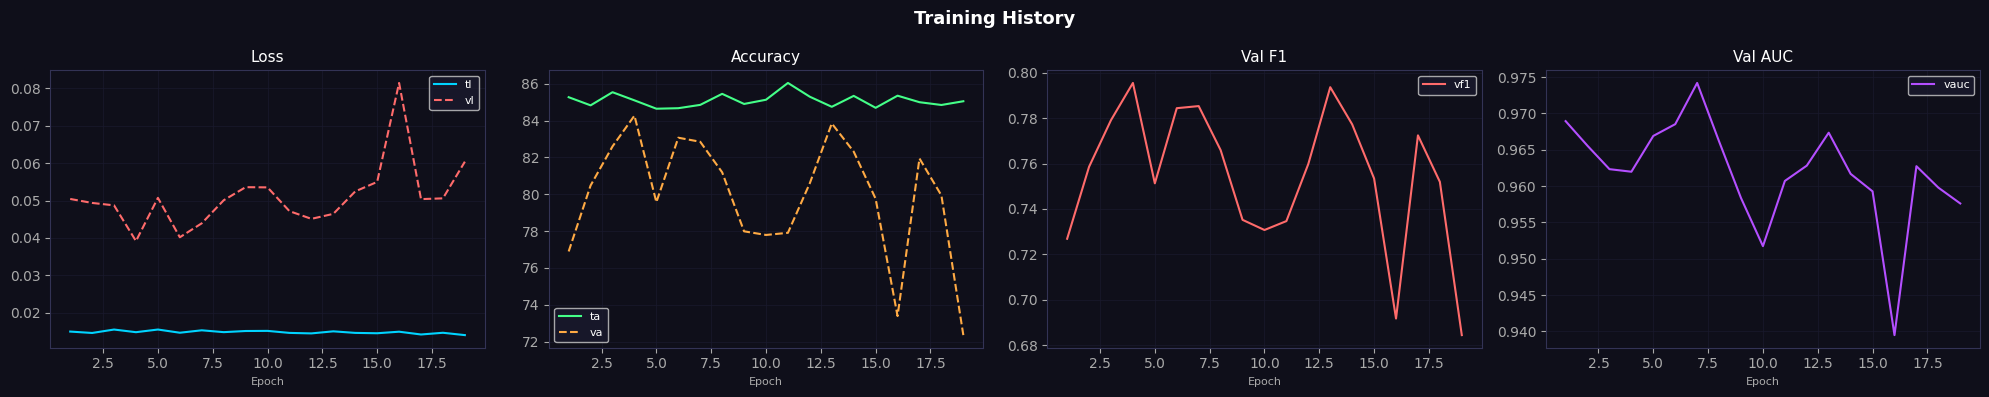

In [ ]:
def plot_history(history):
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    fig.patch.set_facecolor(BG)
    plots = [
        ('tl','vl','Loss',     '#00d4ff','#ff6b6b'),
        ('ta','va','Accuracy', '#44ff88','#ffaa44'),
        ('vf1',None,'Val F1',  '#ff6b6b',None),
        ('vauc',None,'Val AUC','#b44fff',None),
    ]
    for ax,(k1,k2,title,c1,c2) in zip(axes,plots):
        ax.set_facecolor(BG)
        ep = range(1, len(history[k1])+1)
        ax.plot(ep, history[k1], color=c1, lw=1.5, label=k1)
        if k2: ax.plot(ep, history[k2], color=c2, lw=1.5, ls='--', label=k2)
        ax.set_title(title, color='white', fontsize=11)
        ax.set_xlabel('Epoch', color='#aaaaaa', fontsize=8)
        ax.tick_params(colors='#aaaaaa')
        ax.grid(True, color='#1a1a2e', lw=0.5)
        ax.legend(facecolor='#1a1a2e', labelcolor='white', fontsize=8)
        for sp in ax.spines.values(): sp.set_color('#333355')
    fig.suptitle('Training History', color='white', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('training_history.png', dpi=150, bbox_inches='tight', facecolor=BG)
    plt.show()

plot_history(history)

## 📌 Step 12 — Threshold Optimization
Default 0.5 threshold is suboptimal for imbalanced data.
We sweep thresholds on the **validation set** and pick the one maximizing Macro F1.

In [ ]:
def optimize_threshold(model, val_loader):
    _, _, _, _, _, probs, labels = run_epoch(model, val_loader)
    best_f1, best_t = 0, 0.5
    for t in np.arange(0.05, 0.95, 0.01):
        preds = (probs >= t).astype(int)
        f1    = f1_score(labels, preds, average='macro', zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t

    default_f1 = f1_score(labels, (probs>=0.5).astype(int), average='macro')
    print(f'✅ Threshold optimization complete')
    print(f'   Default  (0.50) → F1: {default_f1:.4f}')
    print(f'   Optimal  ({best_t:.2f}) → F1: {best_f1:.4f}')
    print(f'   Gain     : +{best_f1 - default_f1:.4f}')
    return best_t

optimal_threshold = optimize_threshold(model, val_loader)

✅ Threshold optimization complete
   Default  (0.50) → F1: 0.7853
   Optimal  (0.93) → F1: 0.9181
   Gain     : +0.1328


## 📌 Step 13 — Full Test Set Evaluation

In [ ]:
def full_evaluation(model, test_loader, threshold):
    _, _, _, _, _, probs, labels = run_epoch(model, test_loader)
    preds    = (probs >= threshold).astype(int)
    acc      = 100 * (preds == labels).mean()
    f1       = f1_score(labels, preds, average='macro',    zero_division=0)
    prec     = precision_score(labels, preds, average='macro', zero_division=0)
    rec      = recall_score(labels, preds, average='macro',    zero_division=0)
    auc      = roc_auc_score(labels, probs)
    ap       = average_precision_score(labels, probs)
    cm       = confusion_matrix(labels, preds)

    print('═'*60)
    print('  FINAL TEST SET RESULTS')
    print('═'*60)
    print(f'  Threshold        : {threshold:.2f} (val-optimized)')
    print(f'  Accuracy         : {acc:.2f}%')
    print(f'  Macro F1         : {f1:.4f}')
    print(f'  Precision        : {prec:.4f}')
    print(f'  Recall           : {rec:.4f}')
    print(f'  ROC-AUC          : {auc:.4f}')
    print(f'  Avg Precision    : {ap:.4f}')
    print(f'\n{classification_report(labels, preds, target_names=["Normal","Anomaly"], zero_division=0)}')
    return dict(acc=acc,f1=f1,prec=prec,rec=rec,auc=auc,ap=ap,
                preds=preds,probs=probs,labels=labels,cm=cm)

results = full_evaluation(model, test_loader, optimal_threshold)

════════════════════════════════════════════════════════════
  FINAL TEST SET RESULTS
════════════════════════════════════════════════════════════
  Threshold        : 0.93 (val-optimized)
  Accuracy         : 90.34%
  Macro F1         : 0.6054
  Precision        : 0.8168
  Recall           : 0.5764
  ROC-AUC          : 0.8115
  Avg Precision    : 0.3790

              precision    recall  f1-score   support

      Normal       0.91      0.99      0.95     15694
     Anomaly       0.73      0.16      0.26      1886

    accuracy                           0.90     17580
   macro avg       0.82      0.58      0.61     17580
weighted avg       0.89      0.90      0.87     17580



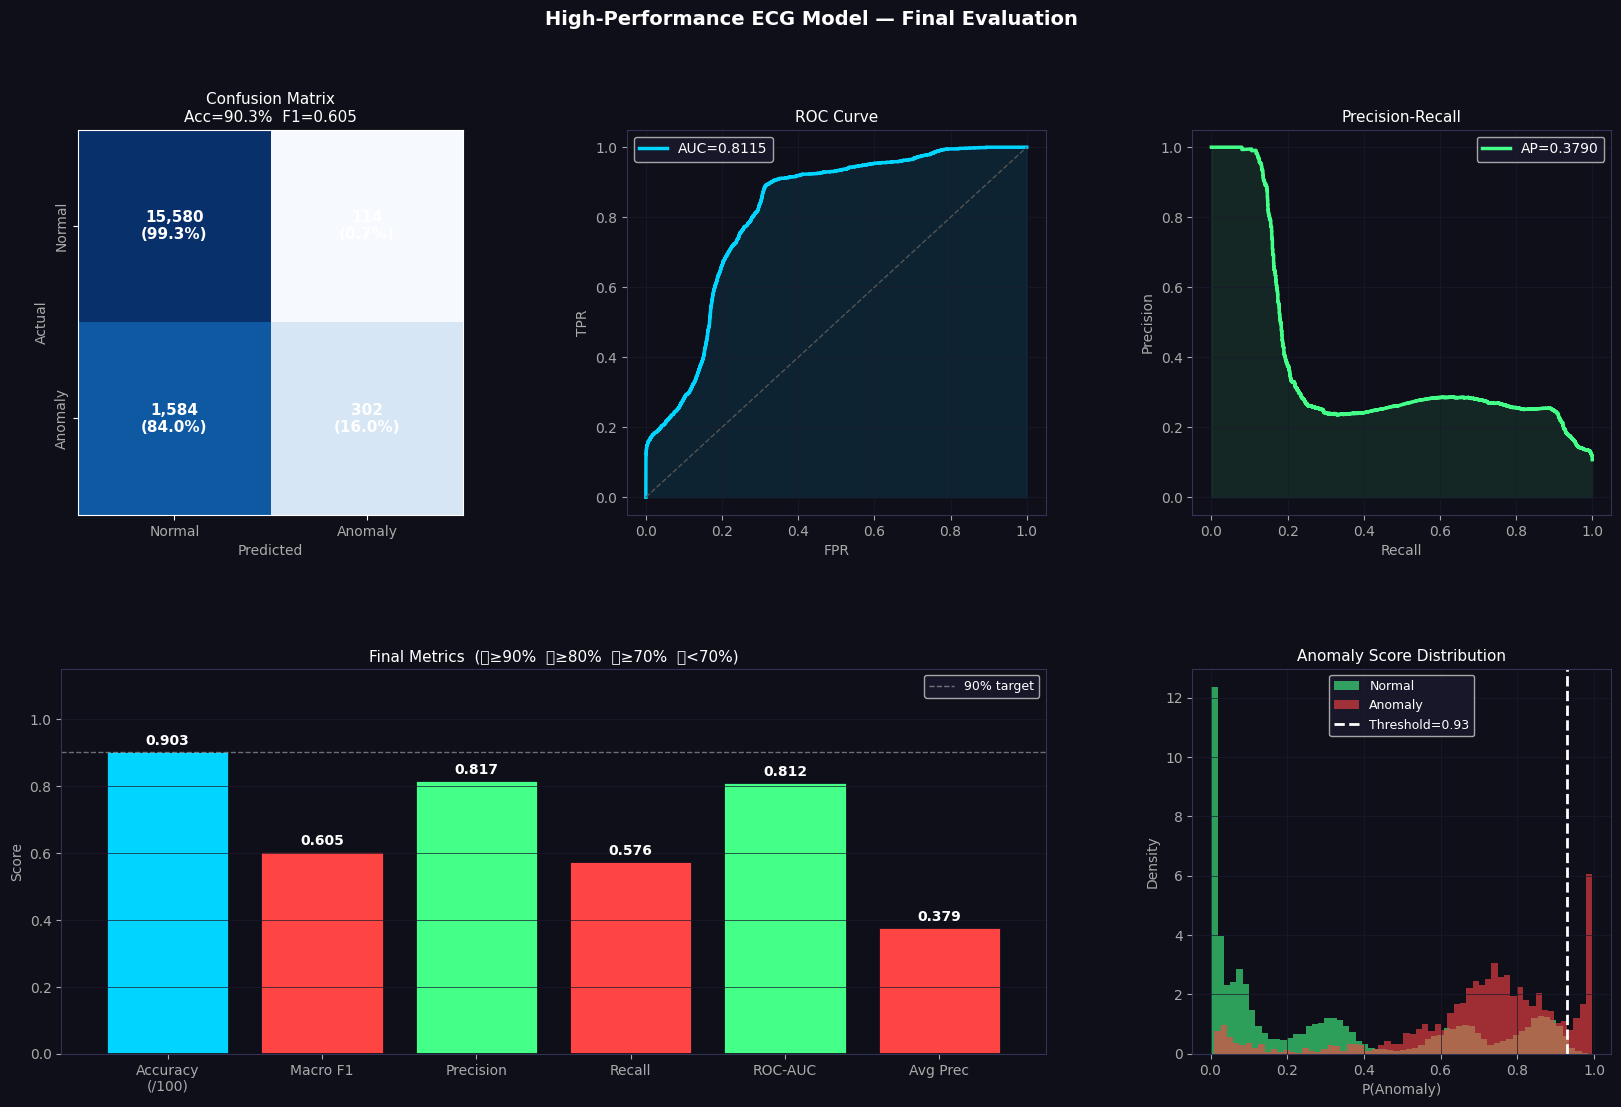

✅ Saved final_evaluation.png


In [ ]:
def plot_evaluation(results, threshold):
    fig = plt.figure(figsize=(20, 12))
    fig.patch.set_facecolor(BG)
    gs  = gridspec.GridSpec(2, 3, hspace=0.4, wspace=0.35)

    # Confusion matrix
    ax1 = fig.add_subplot(gs[0,0]); ax1.set_facecolor(BG)
    cm  = results['cm']
    cmn = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    ax1.imshow(cmn, cmap='Blues', vmin=0, vmax=1)
    for i in range(2):
        for j in range(2):
            ax1.text(j,i,f'{cm[i,j]:,}\n({cmn[i,j]*100:.1f}%)',
                     ha='center',va='center',color='white',fontsize=11,fontweight='bold')
    ax1.set_xticks([0,1]); ax1.set_xticklabels(['Normal','Anomaly'],color='#aaaaaa')
    ax1.set_yticks([0,1]); ax1.set_yticklabels(['Normal','Anomaly'],color='#aaaaaa',rotation=90,va='center')
    ax1.set_xlabel('Predicted',color='#aaaaaa'); ax1.set_ylabel('Actual',color='#aaaaaa')
    ax1.set_title(f'Confusion Matrix\nAcc={results["acc"]:.1f}%  F1={results["f1"]:.3f}',color='white',fontsize=11)

    # ROC curve
    ax2 = fig.add_subplot(gs[0,1]); ax2.set_facecolor(BG)
    fpr,tpr,_ = roc_curve(results['labels'],results['probs'])
    ax2.plot(fpr,tpr,color='#00d4ff',lw=2.5,label=f'AUC={results["auc"]:.4f}')
    ax2.fill_between(fpr,tpr,alpha=0.1,color='#00d4ff')
    ax2.plot([0,1],[0,1],'--',color='#555555',lw=1)
    ax2.set_title('ROC Curve',color='white',fontsize=11)
    ax2.set_xlabel('FPR',color='#aaaaaa'); ax2.set_ylabel('TPR',color='#aaaaaa')
    ax2.legend(facecolor='#1a1a2e',labelcolor='white',fontsize=10)
    ax2.tick_params(colors='#aaaaaa'); ax2.grid(True,color='#1a1a2e',lw=0.5)
    for sp in ax2.spines.values(): sp.set_color('#333355')

    # PR curve
    ax3 = fig.add_subplot(gs[0,2]); ax3.set_facecolor(BG)
    pr,rc,_ = precision_recall_curve(results['labels'],results['probs'])
    ax3.plot(rc,pr,color='#44ff88',lw=2.5,label=f'AP={results["ap"]:.4f}')
    ax3.fill_between(rc,pr,alpha=0.1,color='#44ff88')
    ax3.set_title('Precision-Recall',color='white',fontsize=11)
    ax3.set_xlabel('Recall',color='#aaaaaa'); ax3.set_ylabel('Precision',color='#aaaaaa')
    ax3.legend(facecolor='#1a1a2e',labelcolor='white',fontsize=10)
    ax3.tick_params(colors='#aaaaaa'); ax3.grid(True,color='#1a1a2e',lw=0.5)
    for sp in ax3.spines.values(): sp.set_color('#333355')

    # Metric bar
    ax4 = fig.add_subplot(gs[1,:2]); ax4.set_facecolor(BG)
    m_names = ['Accuracy\n(/100)','Macro F1','Precision','Recall','ROC-AUC','Avg Prec']
    m_vals  = [results['acc']/100,results['f1'],results['prec'],
               results['rec'],results['auc'],results['ap']]
    bcolors = ['#00d4ff' if v>=0.9 else '#44ff88' if v>=0.8
               else '#ffaa44' if v>=0.7 else '#ff4444' for v in m_vals]
    bars = ax4.bar(m_names,m_vals,color=bcolors,edgecolor=BG,linewidth=2)
    for bar,v in zip(bars,m_vals):
        ax4.text(bar.get_x()+bar.get_width()/2.,bar.get_height()+0.01,
                 f'{v:.3f}',ha='center',va='bottom',color='white',fontsize=10,fontweight='bold')
    ax4.axhline(0.9,color='white',ls='--',alpha=0.4,lw=1,label='90% target')
    ax4.set_ylim(0,1.15); ax4.set_ylabel('Score',color='#aaaaaa')
    ax4.set_title('Final Metrics  (🟦≥90%  🟩≥80%  🟧≥70%  🟥<70%)',color='white',fontsize=11)
    ax4.tick_params(colors='#aaaaaa'); ax4.legend(facecolor='#1a1a2e',labelcolor='white',fontsize=9)
    ax4.grid(True,axis='y',color='#1a1a2e',lw=0.5)
    for sp in ax4.spines.values(): sp.set_color('#333355')

    # Score distribution
    ax5 = fig.add_subplot(gs[1,2]); ax5.set_facecolor(BG)
    ax5.hist(results['probs'][results['labels']==0],bins=60,color='#44ff88',
             alpha=0.6,density=True,label='Normal')
    ax5.hist(results['probs'][results['labels']==1],bins=60,color='#ff4444',
             alpha=0.6,density=True,label='Anomaly')
    ax5.axvline(threshold,color='white',ls='--',lw=2,label=f'Threshold={threshold:.2f}')
    ax5.set_title('Anomaly Score Distribution',color='white',fontsize=11)
    ax5.set_xlabel('P(Anomaly)',color='#aaaaaa'); ax5.set_ylabel('Density',color='#aaaaaa')
    ax5.legend(facecolor='#1a1a2e',labelcolor='white',fontsize=9)
    ax5.tick_params(colors='#aaaaaa'); ax5.grid(True,color='#1a1a2e',lw=0.5)
    for sp in ax5.spines.values(): sp.set_color('#333355')

    fig.suptitle('High-Performance ECG Model — Final Evaluation',
                 color='white',fontsize=14,fontweight='bold')
    plt.savefig('final_evaluation.png',dpi=150,bbox_inches='tight',facecolor=BG)
    plt.show()
    print('✅ Saved final_evaluation.png')

plot_evaluation(results, optimal_threshold)

## 📌 Step 14 — Save Model, Scalers & Final Summary

In [ ]:
# Save model + scalers + config
torch.save({
    'model_state'       : model.state_dict(),
    'optimal_threshold' : float(optimal_threshold),
    'config': {
        'segment_len'  : SEGMENT_LEN,
        'window_before': WINDOW_BEFORE,
        'window_after' : WINDOW_AFTER,
        'fs'           : FS,
        'hidden_size'  : HIDDEN_SIZE,
        'num_layers'   : NUM_LAYERS,
        'dropout'      : DROPOUT,
    },
    'results': {k: float(v) for k,v in results.items()
                if isinstance(v, (float,np.floating))}
}, os.path.join(MODEL_SAVE_DIR, 'hp_ecg_final.pt'))

with open(os.path.join(MODEL_SAVE_DIR,'rr_scaler.pkl'),   'wb') as f: pickle.dump(rr_scaler,f)
with open(os.path.join(MODEL_SAVE_DIR,'morph_scaler.pkl'),'wb') as f: pickle.dump(morph_scaler,f)

print('✅ Saved to Google Drive:')
print(f'   {MODEL_SAVE_DIR}/hp_ecg_final.pt')
print(f'   {MODEL_SAVE_DIR}/rr_scaler.pkl')
print(f'   {MODEL_SAVE_DIR}/morph_scaler.pkl')
print()
print('═'*60)
print('  FINAL RESULTS SUMMARY')
print('═'*60)
print(f'  Accuracy         : {results["acc"]:.2f}%')
print(f'  Macro F1         : {results["f1"]:.4f}')
print(f'  Precision        : {results["prec"]:.4f}')
print(f'  Recall           : {results["rec"]:.4f}')
print(f'  ROC-AUC          : {results["auc"]:.4f}')
print(f'  Avg Precision    : {results["ap"]:.4f}')
print(f'  Optimal Threshold: {optimal_threshold:.2f}')
print('═'*60)
print()
print('🚀 Next: Real-Time Anomaly Detection Dashboard')

✅ Saved to Google Drive:
   /content/drive/MyDrive/mit-bih-v2-models/hp_ecg_final.pt
   /content/drive/MyDrive/mit-bih-v2-models/rr_scaler.pkl
   /content/drive/MyDrive/mit-bih-v2-models/morph_scaler.pkl

════════════════════════════════════════════════════════════
  FINAL RESULTS SUMMARY
════════════════════════════════════════════════════════════
  Accuracy         : 90.34%
  Macro F1         : 0.6054
  Precision        : 0.8168
  Recall           : 0.5764
  ROC-AUC          : 0.8115
  Avg Precision    : 0.3790
  Optimal Threshold: 0.93
════════════════════════════════════════════════════════════

🚀 Next: Real-Time Anomaly Detection Dashboard


---
## ✅ Pipeline Complete!

### Files saved to `mit-bih-v2-models/` on Google Drive
| File | Contents |
|------|---------|
| `hp_ecg_final.pt` | Model weights + threshold + config |
| `rr_scaler.pkl` | RR feature scaler (needed for inference) |
| `morph_scaler.pkl` | Morphological feature scaler |

### Architecture at a Glance
| Block | Detail |
|---|---|
| Input | Dual-channel (MLII+V1), 280 samples, 778ms |
| Multi-Scale CNN | Kernels 3/7/15 → 192 channels → pool |
| BiLSTM | 3 layers, 256 hidden × 2 = 512 |
| Attention | 8-head self-attention, residual + LayerNorm |
| Fusion | +RR(6) +Morphology(24) → LayerNorm |
| Classifier | 542→256→128→2 with GELU + Dropout |
| Loss | Focal + Label Smoothing |
| Augmentation | Amplitude scaling + noise + Mixup |

### 🚀 Next Step: Real-Time Dashboard